# DNN Final Project AutoEncoder Morteza Bigdeli 40261662001

##the declared network in project

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:02<00:00, 4578575.74it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 133789.65it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



...

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 4430355.53it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



/usr/local/lib/python3.10/dist-packages/torch/nn/modules/conv.py:952: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv_transpose2d(
/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/20, Train Loss: 2.1919, 0.0973, Val Loss: 2.0668, 0.0692
Epoch 2/20, Train Loss: 2.1014, 0.0724, Val Loss: 1.9980, 0.0668
Epoch 3/20, Train Loss: 2.0672, 0.0704, Val Loss: 1.9643, 0.0651
Epoch 4/20, Train Loss: 2.0457, 0.0691, Val Loss: 1.9415, 0.0637
Epoch 5/20, Train Loss: 2.0299, 0.0682, Val Loss: 1.9246, 0.0637
Epoch 6/20, Train Loss: 2.0190, 0.0678, Val Loss: 1.9083, 0.0633
Epoch 7/20, Train Loss: 2.0118, 0.0676, Val Loss: 1.9053, 0.0631
Epoch 8/20, Train Loss: 2.0049, 0.0675, Val Loss: 1.8950, 0.0628
Epoch 9/20, Train Loss: 1.9958, 0.0673, Val Loss: 1.8899, 0.0629
Epoch 10/20, Train Loss: 1.9927, 0.0673, Val Loss: 1.8839, 0.0629
Epoch 11/20, Train Loss: 1.9835, 0.0672, Val Loss: 1.8820, 0.0628
Epoch 12/20, Train Loss: 1.9813, 0.0671, Val Loss: 1.8797, 0.0628
Epoch 13/20, Train Loss: 1.9793, 0.0670, Val Loss: 1.8788, 0.0626
Epoch 14/20, Train Loss: 1.9772, 0.0669, Val Loss: 1.8735, 0.0625
Epoch 15/20, Train Loss: 1.9762, 0.0669, Val Loss: 1.8689, 0.0624
Epoch 16/20, Train 

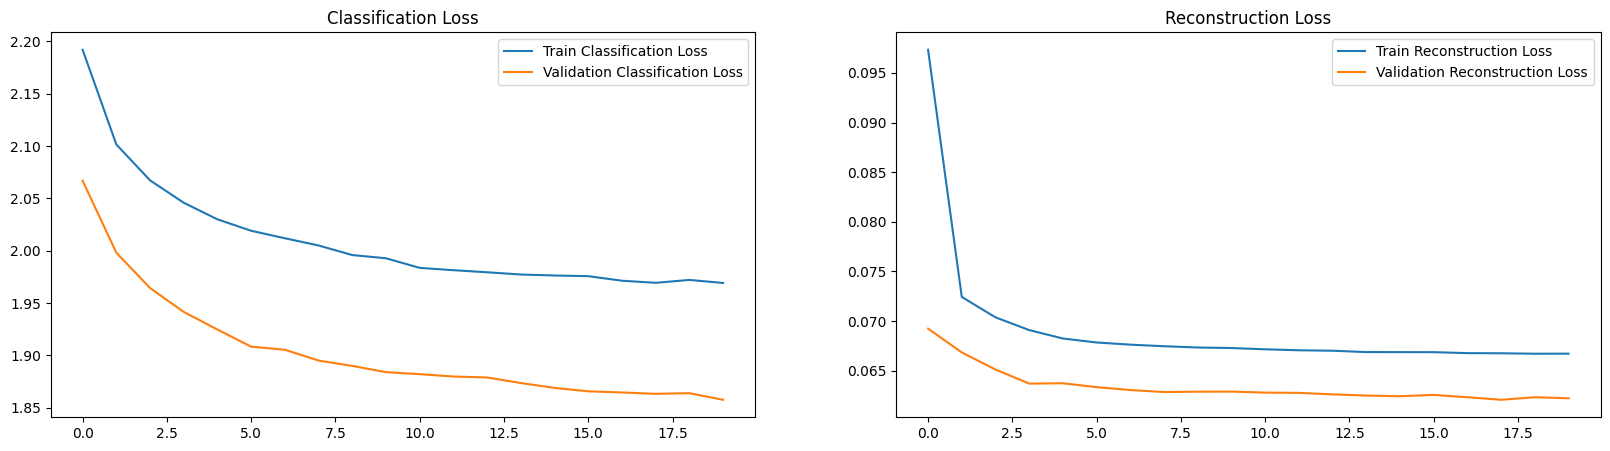

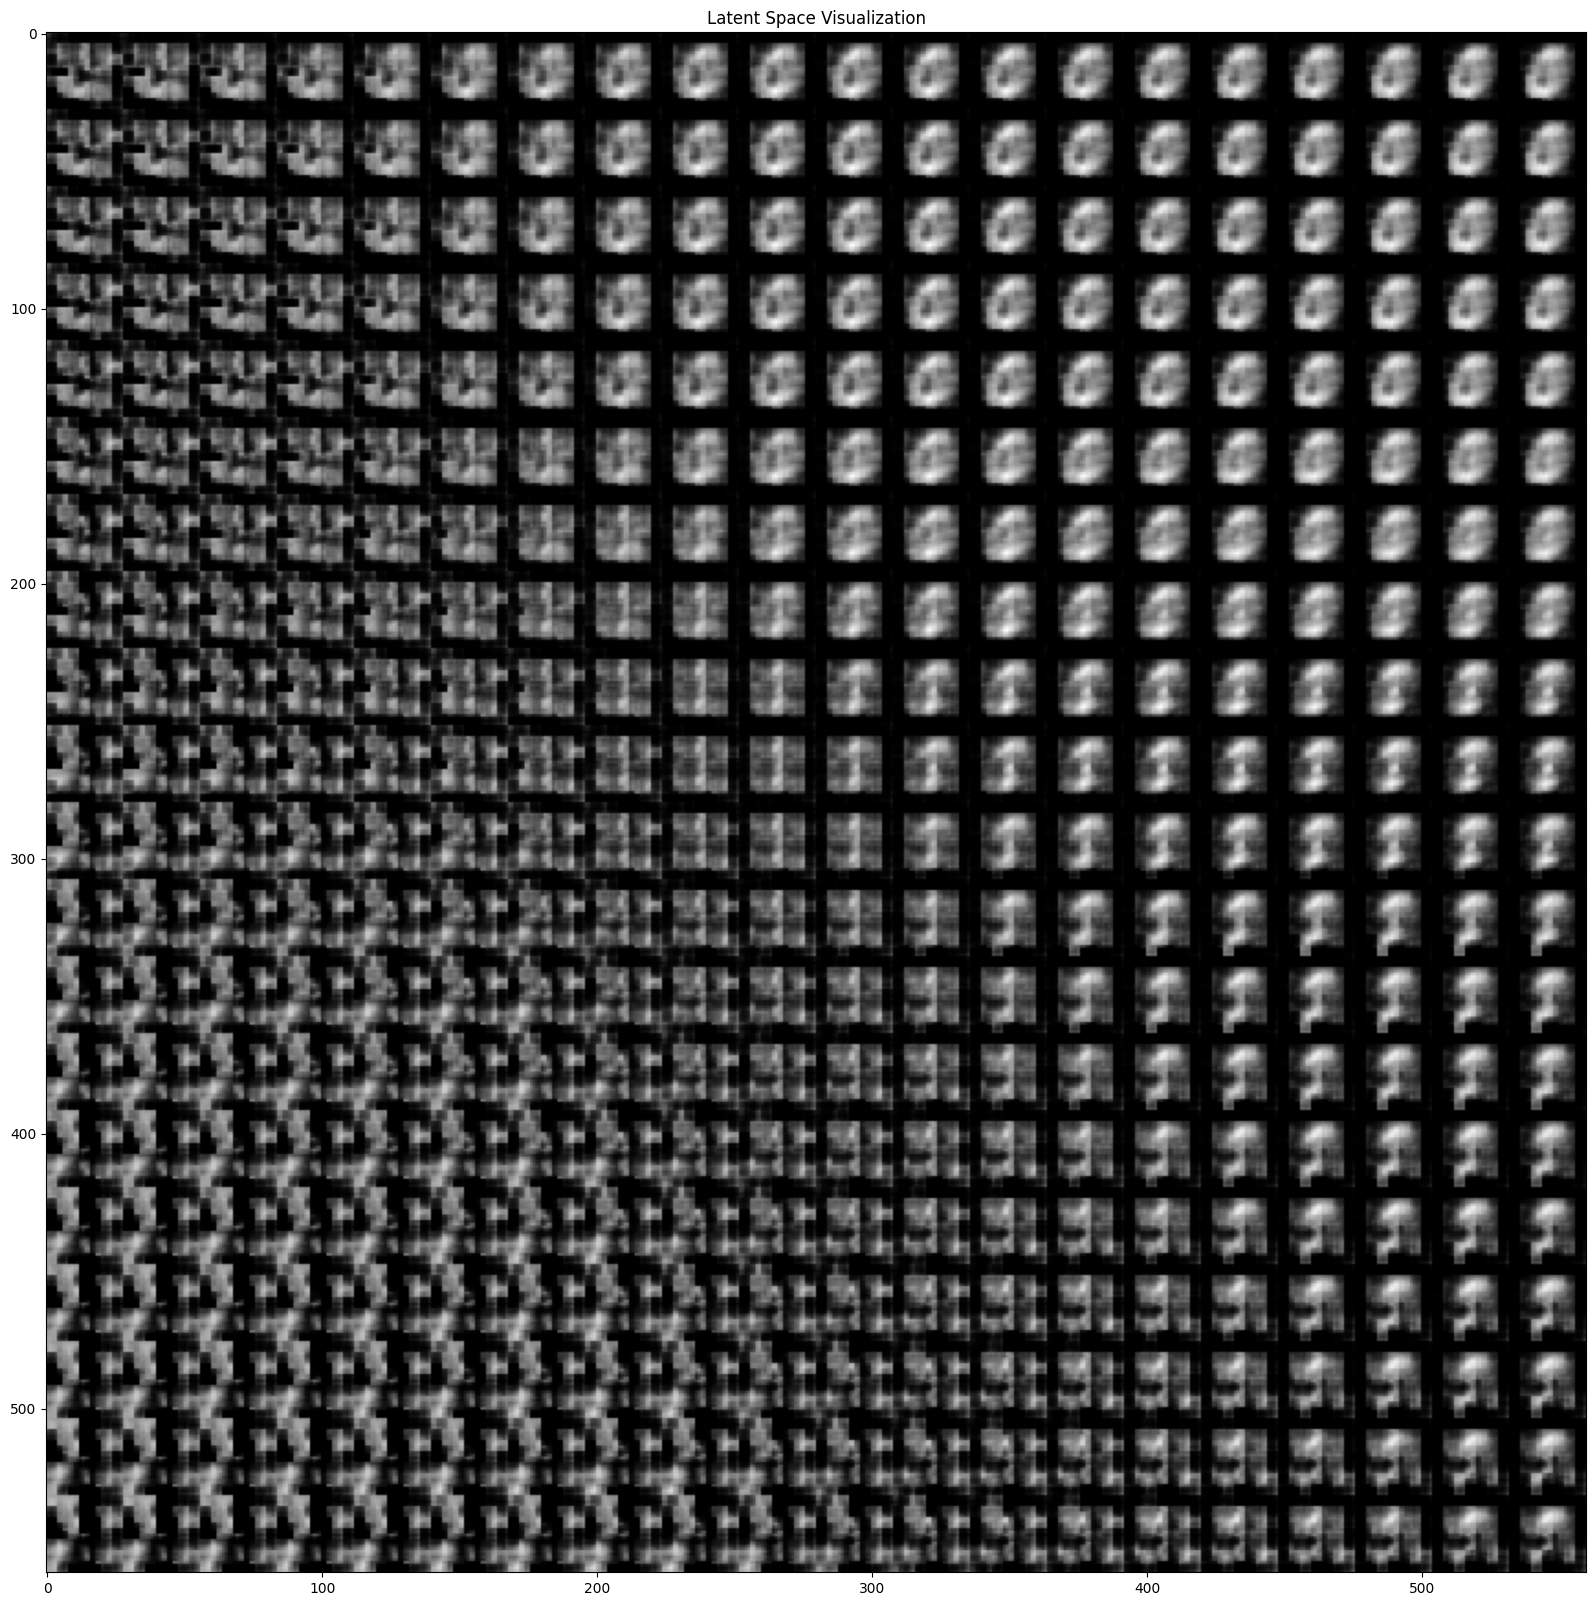

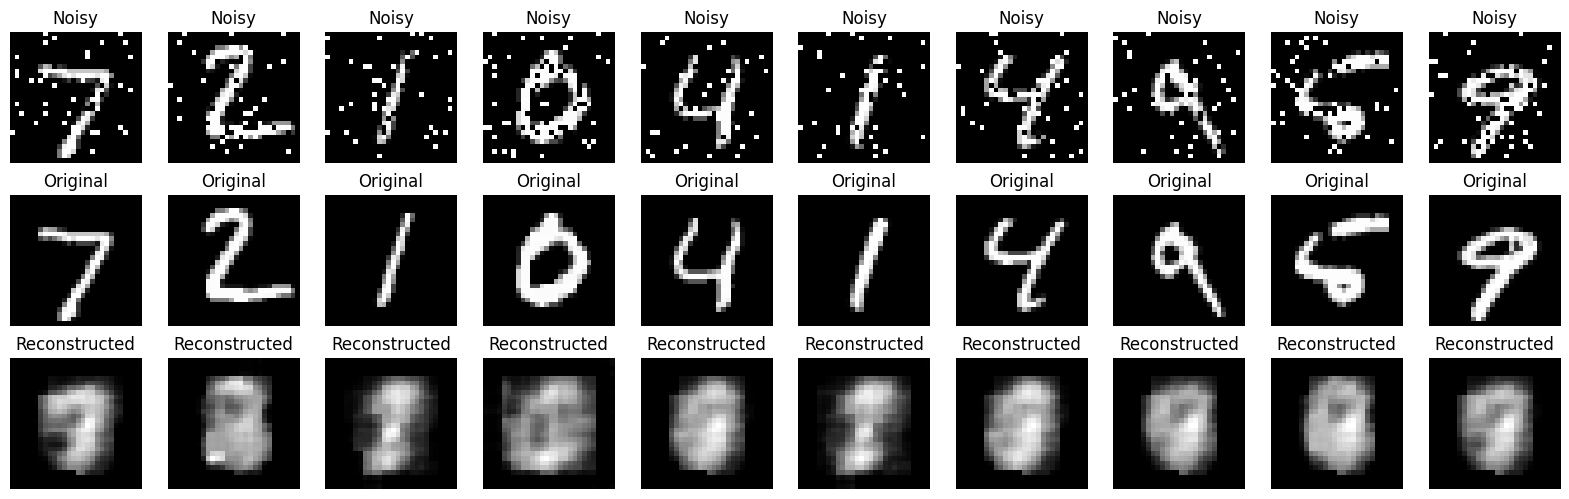

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Add 10% salt and pepper noise
def add_salt_and_pepper_noise(images, amount=0.1):
    noisy_imgs = images.clone()
    num_salt = np.ceil(amount * images[0].numel() * 0.5)
    num_pepper = np.ceil(amount * images[0].numel() * 0.5)

    for img in noisy_imgs:
        # Add salt
        coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img.shape]
        img[coords] = 1

        # Add pepper
        coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img.shape]
        img[coords] = 0

    return noisy_imgs

# Custom Dataset with added noise
class NoisyMNIST(Dataset):
    def __init__(self, train=True):
        self.mnist = datasets.MNIST(root='./data', train=train, download=True, transform=transforms.ToTensor())
        self.noise_transform = transforms.Compose([
            transforms.RandomApply([transforms.Lambda(lambda x: add_salt_and_pepper_noise(x, amount=0.1))], p=1.0),
            transforms.RandomApply([transforms.Lambda(lambda x: x * (torch.rand_like(x) > 0.1).float())], p=1.0)
        ])

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        img, target = self.mnist[idx]
        noisy_img = self.noise_transform(img)
        return noisy_img, img, target

# Define the autoencoder architecture
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=4, stride=2, padding=0),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Conv2d(8, 6, kernel_size=3, stride=2, padding=0),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Conv2d(6, 4, kernel_size=3, stride=3, padding=0),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Conv2d(4, 2, kernel_size=2, stride=1, padding=0),
            nn.Dropout(0.1),
            nn.ReLU()
        )
        # Classification part
        self.classifier = nn.Sequential(
            nn.Linear(2, 10),
            nn.Softmax(dim=1)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2, 4, kernel_size=2, stride=1, padding=0),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(4, 6, kernel_size=3, stride=3, padding=0),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(6, 8, kernel_size=3, stride=2, padding=0),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(8, 1, kernel_size=4, stride=2, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        encoded_flat = encoded.view(encoded.size(0), -1)
        classification = self.classifier(encoded_flat)
        decoded = self.decoder(encoded)
        return encoded_flat, classification, decoded

# Load data
train_dataset = NoisyMNIST(train=True)
test_dataset = NoisyMNIST(train=False)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Initialize model, loss functions, and optimizer
model = Autoencoder().to(device)
criterion_classification = nn.CrossEntropyLoss()
criterion_reconstruction = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training function
def train(model, train_loader, criterion_classification, criterion_reconstruction, optimizer, alpha=0.5):
    model.train()
    train_loss_classification = 0
    train_loss_reconstruction = 0
    for noisy_imgs, imgs, labels in train_loader:
        noisy_imgs, imgs, labels = noisy_imgs.to(device), imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        encoded, classification, decoded = model(noisy_imgs)

        loss_classification = criterion_classification(classification, labels)
        loss_reconstruction = criterion_reconstruction(decoded, imgs)
        loss = alpha * loss_classification + (1 - alpha) * loss_reconstruction

        loss.backward()
        optimizer.step()

        train_loss_classification += loss_classification.item() * noisy_imgs.size(0)
        train_loss_reconstruction += loss_reconstruction.item() * noisy_imgs.size(0)

    return train_loss_classification / len(train_loader.dataset), train_loss_reconstruction / len(train_loader.dataset)

# Validation function
def validate(model, test_loader, criterion_classification, criterion_reconstruction):
    model.eval()
    val_loss_classification = 0
    val_loss_reconstruction = 0
    with torch.no_grad():
        for noisy_imgs, imgs, labels in test_loader:
            noisy_imgs, imgs, labels = noisy_imgs.to(device), imgs.to(device), labels.to(device)

            encoded, classification, decoded = model(noisy_imgs)

            loss_classification = criterion_classification(classification, labels)
            loss_reconstruction = criterion_reconstruction(decoded, imgs)

            val_loss_classification += loss_classification.item() * noisy_imgs.size(0)
            val_loss_reconstruction += loss_reconstruction.item() * noisy_imgs.size(0)

    return val_loss_classification / len(test_loader.dataset), val_loss_reconstruction / len(test_loader.dataset)

# Training loop
num_epochs = 20
train_loss_classification_list = []
train_loss_reconstruction_list = []
val_loss_classification_list = []
val_loss_reconstruction_list = []

for epoch in range(num_epochs):
    train_loss_classification, train_loss_reconstruction = train(model, train_loader, criterion_classification, criterion_reconstruction, optimizer, alpha=0.5)
    val_loss_classification, val_loss_reconstruction = validate(model, test_loader, criterion_classification, criterion_reconstruction)

    train_loss_classification_list.append(train_loss_classification)
    train_loss_reconstruction_list.append(train_loss_reconstruction)
    val_loss_classification_list.append(val_loss_classification)
    val_loss_reconstruction_list.append(val_loss_reconstruction)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss_classification:.4f}, {train_loss_reconstruction:.4f}, Val Loss: {val_loss_classification:.4f}, {val_loss_reconstruction:.4f}')

# Plot the losses
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

axs[0].plot(train_loss_classification_list, label='Train Classification Loss')
axs[0].plot(val_loss_classification_list, label='Validation Classification Loss')
axs[0].set_title('Classification Loss')
axs[0].legend()

axs[1].plot(train_loss_reconstruction_list, label='Train Reconstruction Loss')
axs[1].plot(val_loss_reconstruction_list, label='Validation Reconstruction Loss')
axs[1].set_title('Reconstruction Loss')
axs[1].legend()

plt.show()

# 2D Latent Space Visualization
def plot_latent_space(model, n=20, figsize=20):
    model.eval()
    x_values = np.linspace(-3, 3, n)
    y_values = np.linspace(-3, 3, n)
    canvas = np.empty((28*n, 28*n))

    for i, yi in enumerate(x_values):
        for j, xi in enumerate(y_values):
            z = torch.Tensor([[xi, yi]]).to(device)
            x_hat = model.decoder(z.view(1, 2, 1, 1)).cpu().detach().numpy()
            canvas[(n-i-1)*28:(n-i)*28, j*28:(j+1)*28] = x_hat[0, 0]

    plt.figure(figsize=(figsize, figsize))
    plt.imshow(canvas, cmap='gray')
    plt.title('Latent Space Visualization')
    plt.show()

plot_latent_space(model, n=20, figsize=20)

# Visualize some test data
def visualize_test_data(model, test_loader):
    model.eval()
    with torch.no_grad():
        noisy_imgs, imgs, labels = next(iter(test_loader))
        noisy_imgs, imgs = noisy_imgs.to(device), imgs.to(device)

        _, _, decoded_imgs = model(noisy_imgs)

        fig, axs = plt.subplots(3, 10, figsize=(20, 6))
        for i in range(10):
            axs[0, i].imshow(noisy_imgs[i].cpu().squeeze(), cmap='gray')
            axs[0, i].set_title('Noisy')
            axs[0, i].axis('off')
            axs[1, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
            axs[1, i].set_title('Original')
            axs[1, i].axis('off')
            axs[2, i].imshow(decoded_imgs[i].cpu().squeeze(), cmap='gray')
            axs[2, i].set_title('Reconstructed')
            axs[2, i].axis('off')
        plt.show()

visualize_test_data(model, test_loader)


# Add neeurons with Noise

Epoch 1, Classification Training Loss: 2.04081768229572
Epoch 2, Classification Training Loss: 1.8806278256973479
Epoch 3, Classification Training Loss: 1.8341543369455886
Epoch 4, Classification Training Loss: 1.8028396329900096
Epoch 5, Classification Training Loss: 1.7826937963205105
Epoch 6, Classification Training Loss: 1.7738866507371605
Epoch 7, Classification Training Loss: 1.7594481221140066
Epoch 8, Classification Training Loss: 1.752566406594665
Epoch 9, Classification Training Loss: 1.7417799731307446
Epoch 10, Classification Training Loss: 1.7356317235208523
Epoch 1, Reconstruction Training Loss: 0.12220620590327645
Epoch 2, Reconstruction Training Loss: 0.11148118027555409
Epoch 3, Reconstruction Training Loss: 0.11015192897462134
Epoch 4, Reconstruction Training Loss: 0.10942957532812538
Epoch 5, Reconstruction Training Loss: 0.10889028262164292
Epoch 6, Reconstruction Training Loss: 0.10854297369591463
Epoch 7, Reconstruction Training Loss: 0.10839964735355459
Epoch 8, 

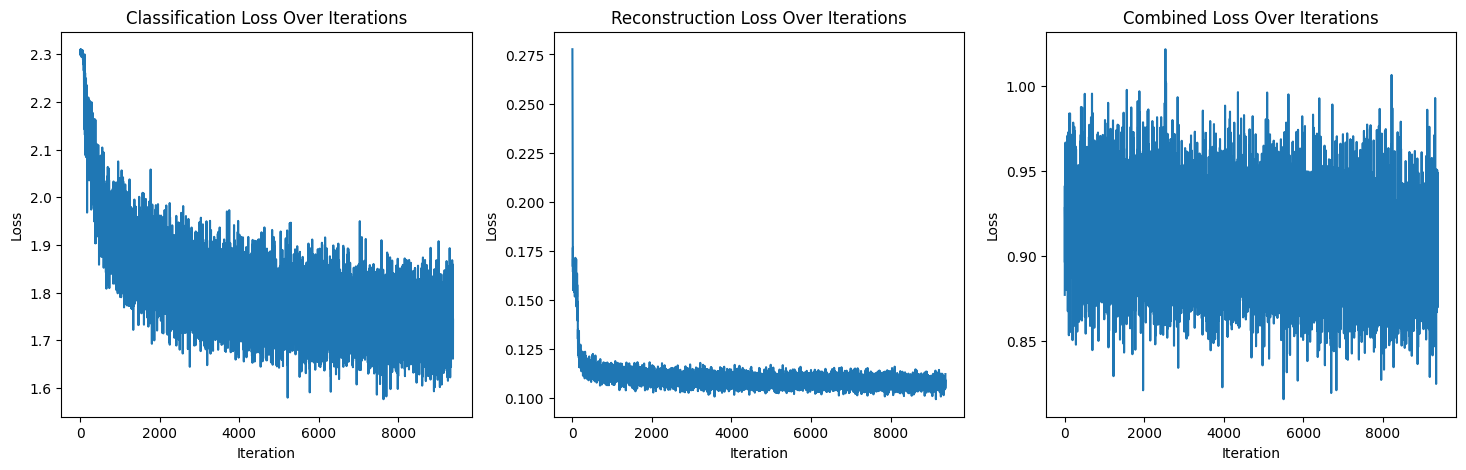

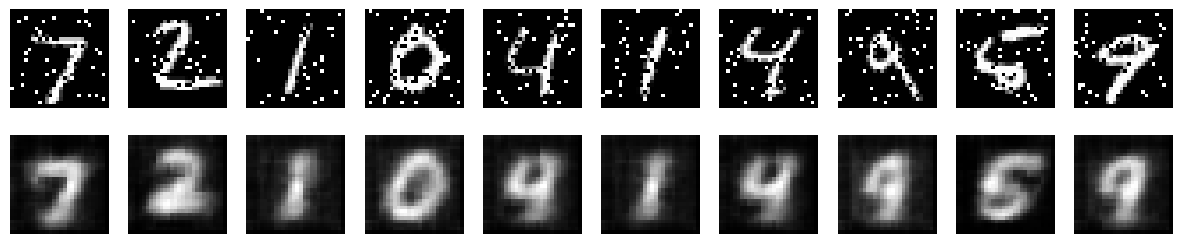

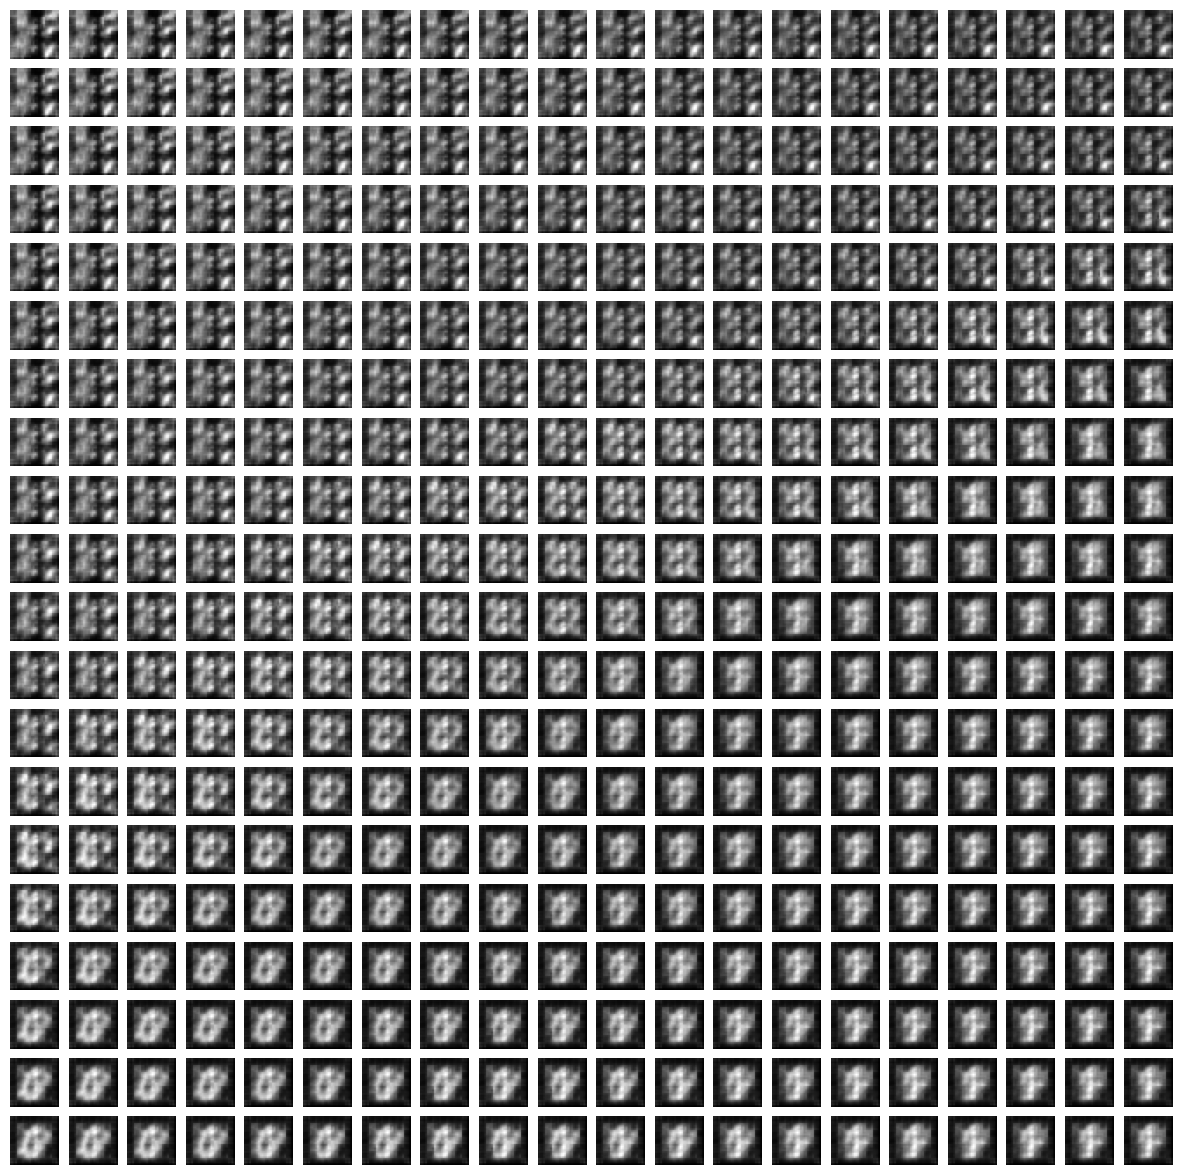

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to add salt and pepper noise
def add_salt_and_pepper_noise(images, amount=0.1):
    noisy_images = images.clone()
    num_salt = np.ceil(amount * images[0].numel() * 0.5)
    for image in noisy_images:
        coords = [np.random.randint(0, i - 1, int(num_salt))
                  for i in image.shape]
        image[coords[0], coords[1]] = 1

        coords = [np.random.randint(0, i - 1, int(num_salt))
                  for i in image.shape]
        image[coords[0], coords[1]] = 0
    return noisy_images

# MNIST dataset with transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: add_salt_and_pepper_noise(x, amount=0.1)),
    transforms.Lambda(lambda x: torch.nn.functional.dropout(x, p=0.1, training=True))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# Define the Autoencoder model
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=0),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Conv2d(16, 12, kernel_size=3, stride=2, padding=0),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Conv2d(12, 8, kernel_size=3, stride=3, padding=0),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Conv2d(8, 4, kernel_size=2, stride=1, padding=0),
            nn.Dropout(0.1),
            nn.ReLU()
        )
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(4 * 1 * 1, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.Softmax(dim=1)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 8, kernel_size=2, stride=1, padding=0),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(8, 12, kernel_size=3, stride=3, padding=0),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(12, 16, kernel_size=3, stride=2, padding=0),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        flattened_latent = latent.view(latent.size(0), -1)
        classification = self.classifier(flattened_latent)
        reconstructed = self.decoder(latent)
        return classification, reconstructed

model = Autoencoder().to(device)

# Define the losses and optimizer
criterion_classification = nn.CrossEntropyLoss()
criterion_reconstruction = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training step function with loss tracking
def train_step(model, train_loader, optimizer, criterion_classification, criterion_reconstruction, alpha, device):
    model.train()
    train_loss = 0
    classification_losses = []
    reconstruction_losses = []

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        classification, reconstructed = model(data)

        # Calculate losses
        classification_loss = criterion_classification(classification, target)
        reconstruction_loss = criterion_reconstruction(reconstructed, data)

        # Combined loss
        loss = alpha * classification_loss + (1 - alpha) * reconstruction_loss
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        classification_losses.append(classification_loss.item())
        reconstruction_losses.append(reconstruction_loss.item())

    return train_loss / len(train_loader), classification_losses, reconstruction_losses

classification_losses_all = []
reconstruction_losses_all = []
combined_losses_all = []

# Train the encoder first for classification
for epoch in range(10):  # Adjust number of epochs as needed
    train_loss, classification_losses, _ = train_step(model, train_loader, optimizer, criterion_classification, criterion_reconstruction, alpha=1.0, device=device)
    classification_losses_all.extend(classification_losses)
    print(f'Epoch {epoch+1}, Classification Training Loss: {train_loss}')

# Train the decoder for reconstruction
for param in model.encoder.parameters():
    param.requires_grad = False

for epoch in range(10):  # Adjust number of epochs as needed
    train_loss, _, reconstruction_losses = train_step(model, train_loader, optimizer, criterion_classification, criterion_reconstruction, alpha=0.0, device=device)
    reconstruction_losses_all.extend(reconstruction_losses)
    print(f'Epoch {epoch+1}, Reconstruction Training Loss: {train_loss}')

# Train both encoder and decoder together
for param in model.encoder.parameters():
    param.requires_grad = True

alpha = 0.5  # Adjust alpha as needed

for epoch in range(10):  # Adjust number of epochs as needed
    train_loss, classification_losses, reconstruction_losses = train_step(model, train_loader, optimizer, criterion_classification, criterion_reconstruction, alpha, device)
    combined_losses_all.extend([(alpha * cl + (1 - alpha) * rl) for cl, rl in zip(classification_losses, reconstruction_losses)])
    print(f'Epoch {epoch+1}, Combined Training Loss: {train_loss}')

# Plot the losses over iterations
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(classification_losses_all, label='Classification Loss')
ax[0].set_title('Classification Loss Over Iterations')
ax[0].set_xlabel('Iteration')
ax[0].set_ylabel('Loss')

ax[1].plot(reconstruction_losses_all, label='Reconstruction Loss')
ax[1].set_title('Reconstruction Loss Over Iterations')
ax[1].set_xlabel('Iteration')
ax[1].set_ylabel('Loss')

ax[2].plot(combined_losses_all, label='Combined Loss')
ax[2].set_title('Combined Loss Over Iterations')
ax[2].set_xlabel('Iteration')
ax[2].set_ylabel('Loss')

plt.show()

# Function to visualize results
def visualize_results(model, test_loader, device):
    model.eval()
    data, _ = next(iter(test_loader))
    data = data.to(device)
    with torch.no_grad():
        classification, reconstructed = model(data)

    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    for i in range(10):
        axes[0, i].imshow(data[i].cpu().numpy().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i].cpu().numpy().squeeze(), cmap='gray')
        axes[1, i].axis('off')
    plt.show()

visualize_results(model, test_loader, device)

# Function to visualize the latent space by generating output for equally spaced 2-D vectors
def visualize_latent_space(model, device):
    model.eval()
    grid_size = 20
    grid_x = np.linspace(-3, 3, grid_size)
    grid_y = np.linspace(-3, 3, grid_size)

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi, 0, 0]])  # Adjust the latent dimension as needed
            z_sample = torch.tensor(z_sample, dtype=torch.float).view(-1, 4, 1, 1).to(device)
            with torch.no_grad():
                x_decoded = model.decoder(z_sample).cpu().numpy().squeeze()
            axes[i, j].imshow(x_decoded, cmap='gray')
            axes[i, j].axis('off')

    plt.show()

visualize_latent_space(model, device)


#Added Layers and neurons no noise

====> Epoch: 1 Average loss: 0.0311
====> Epoch: 2 Average loss: 0.0281
====> Epoch: 3 Average loss: 0.0270
====> Epoch: 4 Average loss: 0.0263
====> Epoch: 5 Average loss: 0.0253
====> Epoch: 6 Average loss: 0.0249
====> Epoch: 7 Average loss: 0.0237
====> Epoch: 8 Average loss: 0.0235
====> Epoch: 9 Average loss: 0.0234
====> Epoch: 10 Average loss: 0.0234
====> Epoch: 11 Average loss: 0.0233
====> Epoch: 12 Average loss: 0.0233
====> Epoch: 13 Average loss: 0.0233
====> Epoch: 14 Average loss: 0.0232
====> Epoch: 15 Average loss: 0.0232
====> Epoch: 16 Average loss: 0.0232
====> Epoch: 17 Average loss: 0.0232
====> Epoch: 18 Average loss: 0.0232
====> Epoch: 19 Average loss: 0.0232
====> Epoch: 20 Average loss: 0.0232
====> Epoch: 21 Average loss: 0.0231
====> Epoch: 22 Average loss: 0.0231
====> Epoch: 23 Average loss: 0.0231
====> Epoch: 24 Average loss: 0.0231
====> Epoch: 25 Average loss: 0.0231
====> Epoch: 26 Average loss: 0.0010
====> Epoch: 27 Average loss: 0.0006
====> Epoc

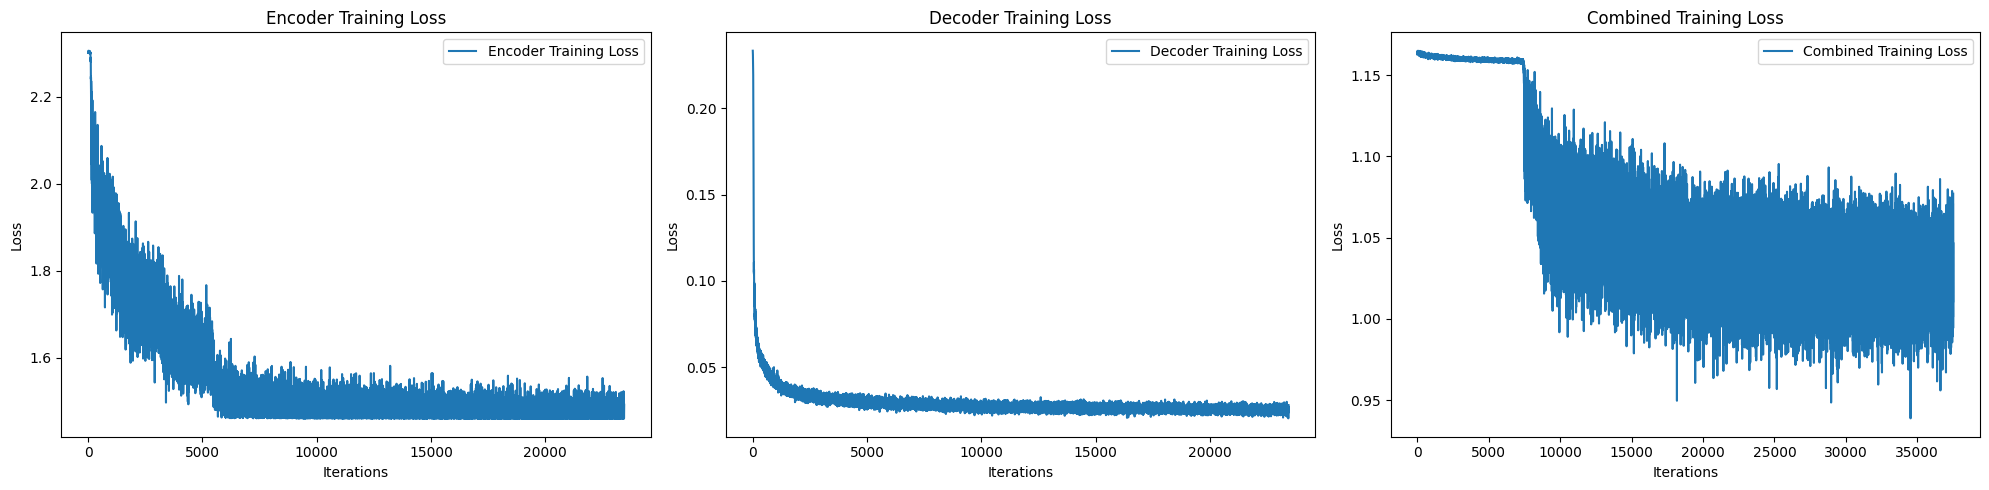

====> Test set loss: 0.0161


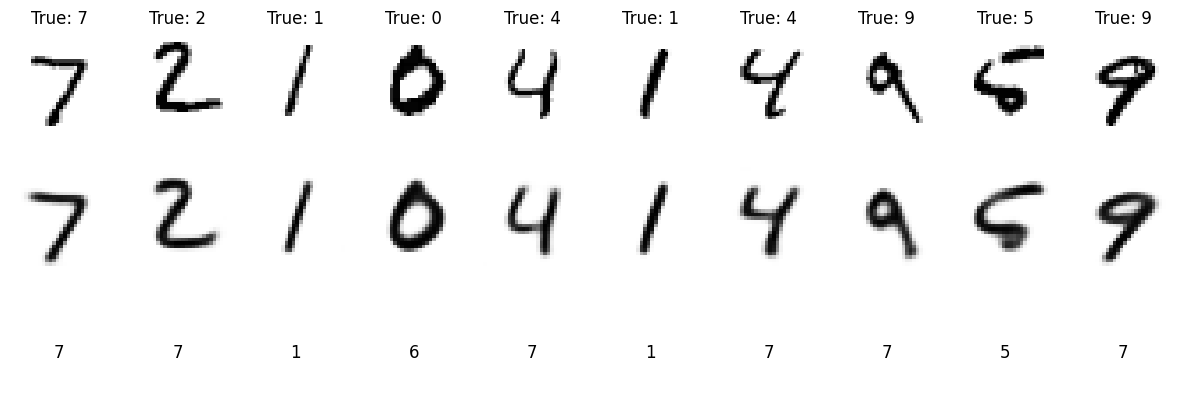

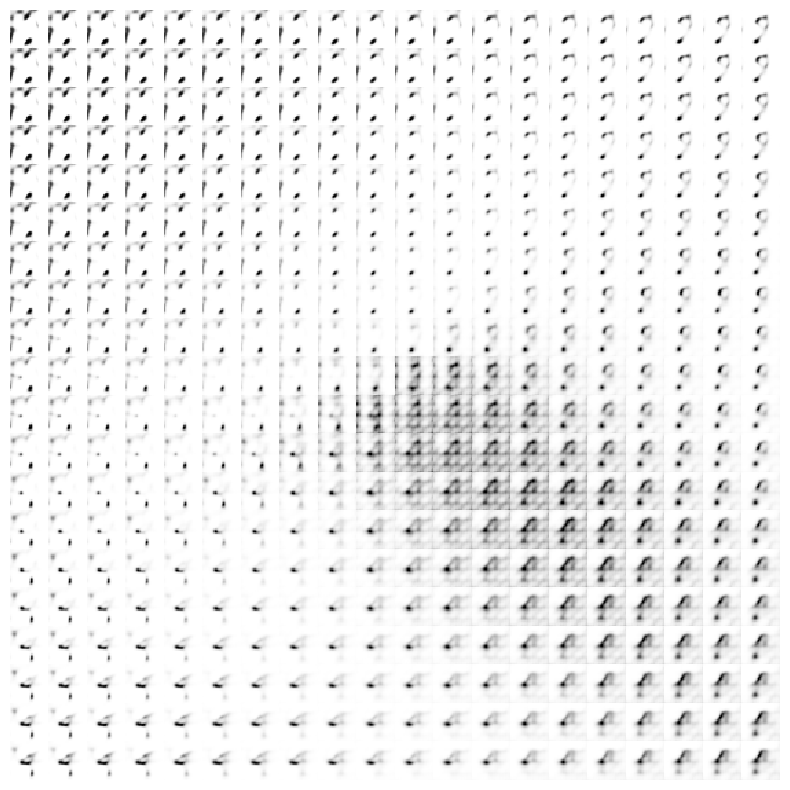

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data transformation
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load datasets
train_dataset = datasets.MNIST('.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('.', train=False, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Define the Autoencoder class with carefully managed dimensions
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # Output: 32 x 14 x 14
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # Output: 64 x 7 x 7
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # Output: 128 x 4 x 4
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # Output: 256 x 2 x 2
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(256, 512, kernel_size=2, stride=1, padding=0),  # Output: 512 x 1 x 1
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        # Classification
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.Linear(32, 10),
            nn.Softmax(dim=1)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=1, padding=0),  # Output: 256 x 2 x 2
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: 128 x 4 x 4
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: 64 x 8 x 8
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: 32 x 16 x 16
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: 1 x 32 x 32
            nn.Conv2d(1, 1, kernel_size=5, stride=1, padding=0),  # Output: 1 x 28 x 28
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        latent_flattened = latent.view(latent.size(0), -1)
        classification = self.classifier(latent_flattened)
        reconstruction = self.decoder(latent.view(latent.size(0), 512, 1, 1))
        return reconstruction, classification, latent

# Define the loss function
def loss_function(reconstruction, x, classification, target, alpha=0.5):
    classification_loss = F.cross_entropy(classification, target)
    reconstruction_loss = F.mse_loss(reconstruction, x)
    return alpha * classification_loss + (1 - alpha) * reconstruction_loss, classification_loss, reconstruction_loss

# Train encoder
def train_encoder(model, train_loader, optimizer, epoch, train_losses):
    model.train()
    for param in model.encoder.parameters():
        param.requires_grad = True
    for param in model.decoder.parameters():
        param.requires_grad = False  # Freeze decoder
    train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        reconstruction, classification, _ = model(data)
        loss, classification_loss, _ = loss_function(reconstruction, data, classification, target, alpha=1.0)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_losses.append(loss.item())
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

# Train decoder
def train_decoder(model, train_loader, optimizer, epoch, train_losses):
    model.train()
    for param in model.encoder.parameters():
        param.requires_grad = False  # Freeze encoder
    for param in model.decoder.parameters():
        param.requires_grad = True
    train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        reconstruction, classification, _ = model(data)
        loss, _, reconstruction_loss = loss_function(reconstruction, data, classification, target, alpha=0.0)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_losses.append(loss.item())
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

# Train both encoder and decoder
def train_both(model, train_loader, optimizer, epoch, train_losses, alpha=0.5):
    model.train()
    for param in model.encoder.parameters():
        param.requires_grad = True
    for param in model.decoder.parameters():
        param.requires_grad = True
    train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        reconstruction, classification, _ = model(data)
        loss, classification_loss, reconstruction_loss = loss_function(reconstruction, data, classification, target, alpha=alpha)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_losses.append(loss.item())
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

# Training the model
model = Autoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

train_losses_encoder = []
train_losses_decoder = []
train_losses_both = []

# Define epoch and learning rate parameters for each phase
epochs_encoder = 25
lr_encoder = 1e-4
epochs_decoder = 25
lr_decoder = 1e-4
epochs_both = 40
lr_both = 1e-5

# Phase 1: Train encoder for classification
optimizer = optim.Adam(model.parameters(), lr=lr_encoder, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
for epoch in range(1, epochs_encoder + 1):
    train_encoder(model, train_loader, optimizer, epoch, train_losses_encoder)
    scheduler.step()

# Phase 2: Train decoder for reconstruction
optimizer = optim.Adam(model.parameters(), lr=lr_decoder, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
for epoch in range(epochs_encoder + 1, epochs_encoder + epochs_decoder + 1):
    train_decoder(model, train_loader, optimizer, epoch, train_losses_decoder)
    scheduler.step()

# Phase 3: Train both together
optimizer = optim.Adam(model.parameters(), lr=lr_both, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
for epoch in range(epochs_encoder + epochs_decoder + 1, epochs_encoder + epochs_decoder + epochs_both + 1):
    train_both(model, train_loader, optimizer, epoch, train_losses_both, alpha=0.5)
    scheduler.step()

# Plot training losses
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses_encoder, label='Encoder Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.title('Encoder Training Loss')

plt.subplot(1, 3, 2)
plt.plot(train_losses_decoder, label='Decoder Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.title('Decoder Training Loss')

plt.subplot(1, 3, 3)
plt.plot(train_losses_both, label='Combined Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.title('Combined Training Loss')

plt.tight_layout()
plt.show()

# Evaluation function
def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            reconstruction, classification, _ = model(data)
            loss, _, _ = loss_function(reconstruction, data, classification, target, alpha=0.5)
            test_loss += loss.item()
    test_loss /= len(test_loader.dataset)
    print(f'====> Test set loss: {test_loss:.4f}')

# Visualization functions
def visualize_results(model, test_loader):
    model.eval()
    data, target = next(iter(test_loader))
    data, target = data.to(device), target.to(device)
    reconstruction, classification, _ = model(data)
    data = data.cpu().numpy()
    reconstruction = reconstruction.cpu().detach().numpy()
    classification = classification.cpu().detach().numpy()

    fig, axes = plt.subplots(3, 10, figsize=(15, 5))
    for i in range(10):
        axes[0, i].imshow(data[i].reshape(28, 28), cmap='gray_r')
        axes[0, i].axis('off')
        axes[0, i].set_title(f'True: {target[i].item()}')
        axes[1, i].imshow(reconstruction[i].reshape(28, 28), cmap='gray_r')
        axes[1, i].axis('off')
        pred_class = np.argmax(classification[i])
        axes[2, i].text(0.5, 0.5, f'{pred_class}', horizontalalignment='center', verticalalignment='center', fontsize=12)
        axes[2, i].axis('off')
    plt.show()

def visualize_latent_space(model, n=20, figsize=(10, 10)):
    model.eval()

    # Generate a grid of 2D latent vectors
    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)

    figure = np.zeros((28 * n, 28 * n))

    # Iterate over the grid and decode each point
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([xi, yi], dtype=torch.float32).view(1, 2).to(device)
            # Expand to match expected input of the decoder
            z_sample = z_sample.repeat(1, 256).view(1, 512, 1, 1)
            with torch.no_grad():
                x_decoded = model.decoder(z_sample)
            digit = x_decoded[0].cpu().detach().numpy().reshape(28, 28)
            digit = (digit - digit.min()) / (digit.max() - digit.min())  # Normalize the digit
            figure[i * 28: (i + 1) * 28, j * 28: (j + 1) * 28] = digit

    plt.figure(figsize=figsize)
    plt.imshow(figure, cmap='gray_r', interpolation='nearest')
    plt.axis('off')
    plt.show()

# Usage example:
evaluate(model, test_loader)
visualize_results(model, test_loader)
visualize_latent_space(model)


## Max Added layers and Neurons with dropouts and noise

====> Epoch: 1 Average loss: 0.0351
====> Epoch: 2 Average loss: 0.0299
====> Epoch: 3 Average loss: 0.0278
====> Epoch: 4 Average loss: 0.0266
====> Epoch: 5 Average loss: 0.0260
====> Epoch: 6 Average loss: 0.0254
====> Epoch: 7 Average loss: 0.0245
====> Epoch: 8 Average loss: 0.0243
====> Epoch: 9 Average loss: 0.0242
====> Epoch: 10 Average loss: 0.0241
====> Epoch: 11 Average loss: 0.0240
====> Epoch: 12 Average loss: 0.0239
====> Epoch: 13 Average loss: 0.0239
====> Epoch: 14 Average loss: 0.0238
====> Epoch: 15 Average loss: 0.0238
====> Epoch: 16 Average loss: 0.0238
====> Epoch: 17 Average loss: 0.0237
====> Epoch: 18 Average loss: 0.0237
====> Epoch: 19 Average loss: 0.0237
====> Epoch: 20 Average loss: 0.0237
====> Epoch: 21 Average loss: 0.0236
====> Epoch: 22 Average loss: 0.0236
====> Epoch: 23 Average loss: 0.0236
====> Epoch: 24 Average loss: 0.0236
====> Epoch: 25 Average loss: 0.0236
====> Epoch: 26 Average loss: 0.0236
====> Epoch: 27 Average loss: 0.0236
====> Epoc

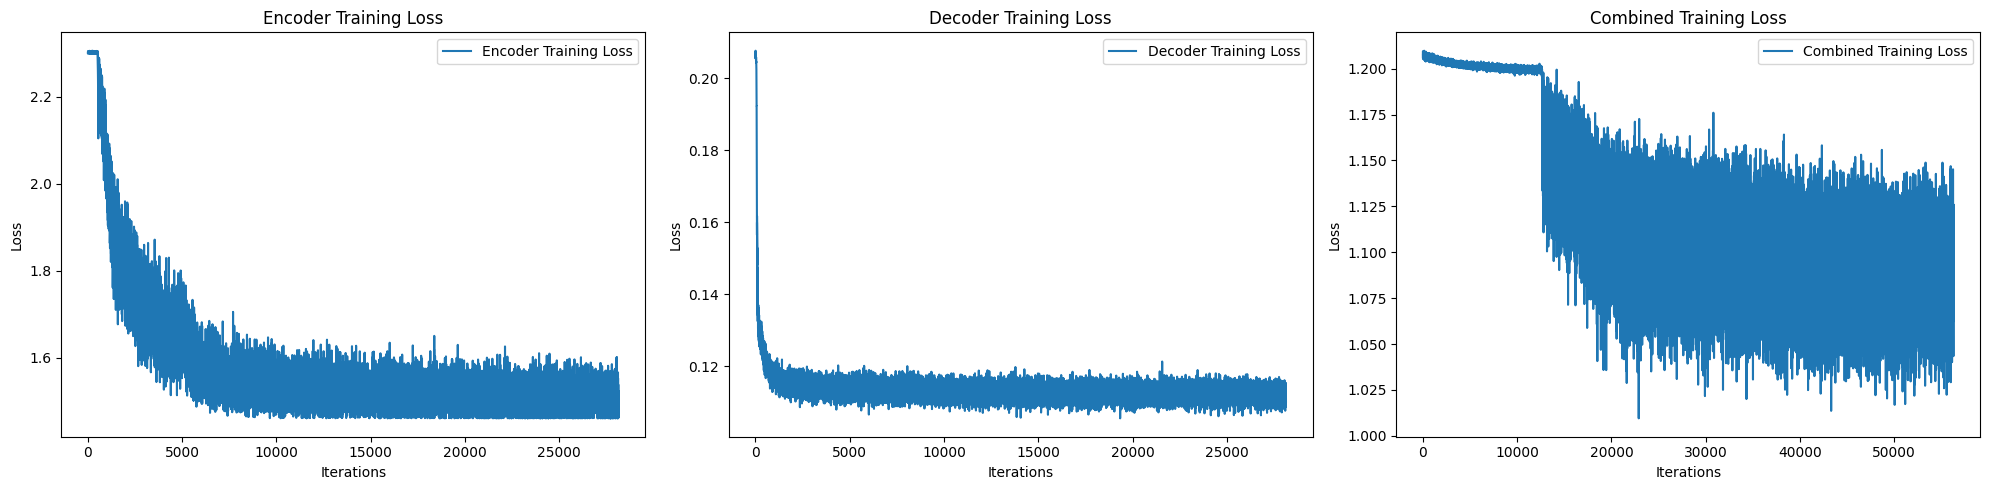

====> Test set loss: 0.0165


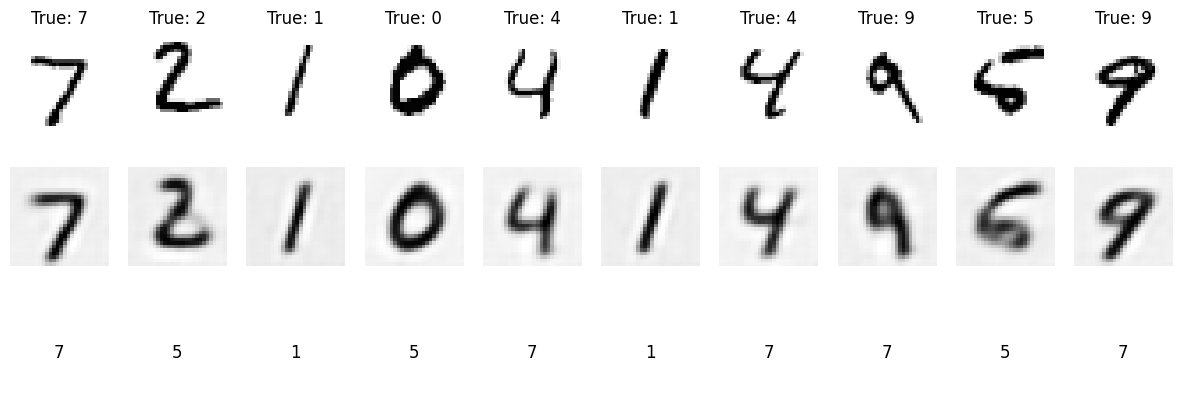

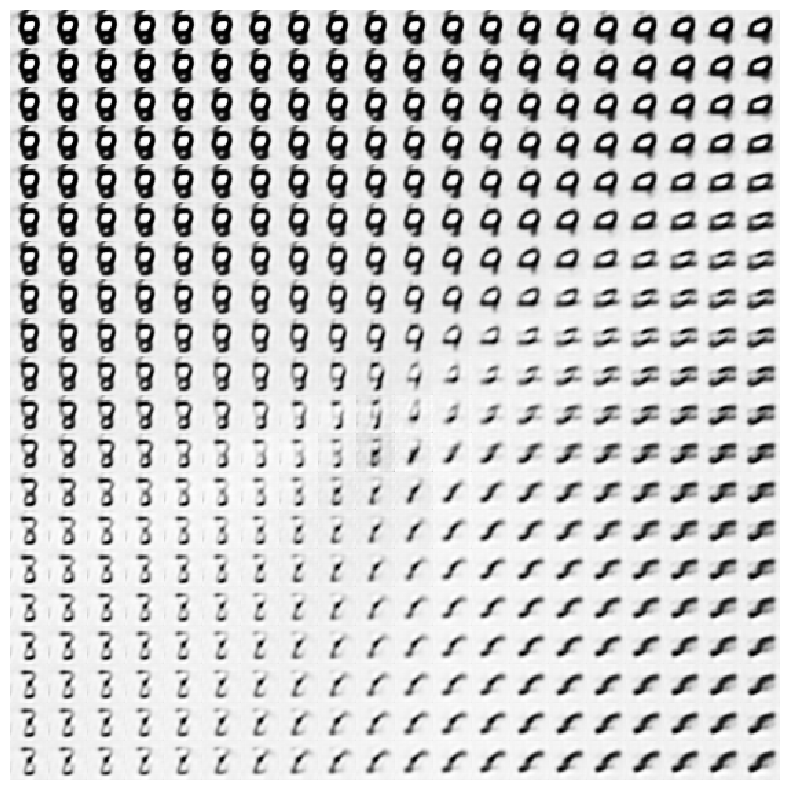

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the SaltPepperNoise class
class SaltPepperNoise(object):
    def __init__(self, salt_prob, pepper_prob):
        self.salt_prob = salt_prob
        self.pepper_prob = pepper_prob

    def __call__(self, img):
        img = np.array(img)
        salt_mask = np.random.rand(*img.shape) < self.salt_prob
        pepper_mask = np.random.rand(*img.shape) < self.pepper_prob
        img[salt_mask] = 1
        img[pepper_mask] = 0
        return torch.tensor(img, dtype=torch.float32)

# Data transformation
transform = transforms.Compose([
    transforms.ToTensor(),
    SaltPepperNoise(salt_prob=0.1, pepper_prob=0.1)
])

# Load datasets
train_dataset = datasets.MNIST('.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('.', train=False, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Define the Autoencoder class with carefully managed dimensions
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # Output: 32 x 14 x 14
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # Output: 64 x 7 x 7
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # Output: 128 x 4 x 4
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # Output: 256 x 2 x 2
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),  # Output: 512 x 1 x 1
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(512, 1024, kernel_size=1, stride=1, padding=0),  # Output: 1024 x 1 x 1
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        # Classification
        self.classifier = nn.Sequential(
            nn.Linear(1024 * 1 * 1, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.Linear(32, 10),
            nn.Softmax(dim=1)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(1024, 512, kernel_size=1, stride=1, padding=0),  # Output: 512 x 1 x 1
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: 256 x 2 x 2
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: 128 x 4 x 4
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: 64 x 8 x 8
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: 32 x 16 x 16
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: 1 x 32 x 32
            nn.Conv2d(1, 1, kernel_size=5, stride=1, padding=0),  # Output: 1 x 28 x 28
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        latent_flattened = latent.view(latent.size(0), -1)
        classification = self.classifier(latent_flattened)
        reconstruction = self.decoder(latent.view(latent.size(0), 1024, 1, 1))
        return reconstruction, classification, latent

# Define the loss function
def loss_function(reconstruction, x, classification, target, alpha=0.5):
    classification_loss = F.cross_entropy(classification, target)
    reconstruction_loss = F.mse_loss(reconstruction, x)
    return alpha * classification_loss + (1 - alpha) * reconstruction_loss, classification_loss, reconstruction_loss

# Train encoder
def train_encoder(model, train_loader, optimizer, epoch, train_losses):
    model.train()
    for param in model.encoder.parameters():
        param.requires_grad = True
    for param in model.decoder.parameters():
        param.requires_grad = False  # Freeze decoder
    train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        reconstruction, classification, _ = model(data)
        loss, classification_loss, _ = loss_function(reconstruction, data, classification, target, alpha=1.0)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_losses.append(loss.item())
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

# Train decoder
def train_decoder(model, train_loader, optimizer, epoch, train_losses):
    model.train()
    for param in model.encoder.parameters():
        param.requires_grad = False  # Freeze encoder
    for param in model.decoder.parameters():
        param.requires_grad = True
    train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        reconstruction, classification, _ = model(data)
        loss, _, reconstruction_loss = loss_function(reconstruction, data, classification, target, alpha=0.0)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_losses.append(loss.item())
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

# Train both encoder and decoder
def train_both(model, train_loader, optimizer, epoch, train_losses, alpha=0.5):
    model.train()
    for param in model.encoder.parameters():
        param.requires_grad = True
    for param in model.decoder.parameters():
        param.requires_grad = True
    train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        reconstruction, classification, _ = model(data)
        loss, classification_loss, reconstruction_loss = loss_function(reconstruction, data, classification, target, alpha=alpha)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_losses.append(loss.item())
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

# Training the model
model = Autoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

train_losses_encoder = []
train_losses_decoder = []
train_losses_both = []

# Define epoch and learning rate parameters for each phase
epochs_encoder = 30
lr_encoder = 1e-4
epochs_decoder = 30
lr_decoder = 1e-4
epochs_both = 60
lr_both = 1e-5

# Phase 1: Train encoder for classification
optimizer = optim.Adam(model.parameters(), lr=lr_encoder, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
for epoch in range(1, epochs_encoder + 1):
    train_encoder(model, train_loader, optimizer, epoch, train_losses_encoder)
    scheduler.step()

# Phase 2: Train decoder for reconstruction
optimizer = optim.Adam(model.parameters(), lr=lr_decoder, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
for epoch in range(epochs_encoder + 1, epochs_encoder + epochs_decoder + 1):
    train_decoder(model, train_loader, optimizer, epoch, train_losses_decoder)
    scheduler.step()

# Phase 3: Train both together
optimizer = optim.Adam(model.parameters(), lr=lr_both, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
for epoch in range(epochs_encoder + epochs_decoder + 1, epochs_encoder + epochs_decoder + epochs_both + 1):
    train_both(model, train_loader, optimizer, epoch, train_losses_both, alpha=0.5)
    scheduler.step()

# Plot training losses
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses_encoder, label='Encoder Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.title('Encoder Training Loss')

plt.subplot(1, 3, 2)
plt.plot(train_losses_decoder, label='Decoder Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.title('Decoder Training Loss')

plt.subplot(1, 3, 3)
plt.plot(train_losses_both, label='Combined Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.title('Combined Training Loss')

plt.tight_layout()
plt.show()

# Evaluation function
def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            reconstruction, classification, _ = model(data)
            loss, _, _ = loss_function(reconstruction, data, classification, target, alpha=0.5)
            test_loss += loss.item()
    test_loss /= len(test_loader.dataset)
    print(f'====> Test set loss: {test_loss:.4f}')

# Visualization functions
def visualize_results(model, test_loader):
    model.eval()
    data, target = next(iter(test_loader))
    data, target = data.to(device), target.to(device)
    reconstruction, classification, _ = model(data)
    data = data.cpu().numpy()
    reconstruction = reconstruction.cpu().detach().numpy()
    classification = classification.cpu().detach().numpy()

    fig, axes = plt.subplots(3, 10, figsize=(15, 5))
    for i in range(10):
        axes[0, i].imshow(data[i].reshape(28, 28), cmap='gray_r')
        axes[0, i].axis('off')
        axes[0, i].set_title(f'True: {target[i].item()}')
        axes[1, i].imshow(reconstruction[i].reshape(28, 28), cmap='gray_r')
        axes[1, i].axis('off')
        pred_class = np.argmax(classification[i])
        axes[2, i].text(0.5, 0.5, f'{pred_class}', horizontalalignment='center', verticalalignment='center', fontsize=12)
        axes[2, i].axis('off')
    plt.show()

def visualize_latent_space(model, n=20, figsize=(10, 10)):
    model.eval()

    # Generate a grid of 2D latent vectors
    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)

    figure = np.zeros((28 * n, 28 * n))

    # Iterate over the grid and decode each point
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([xi, yi], dtype=torch.float32).view(1, 2).to(device)
            # Expand to match expected input of the decoder
            z_sample = z_sample.repeat(1, 512).view(1, 1024, 1, 1)
            with torch.no_grad():
                x_decoded = model.decoder(z_sample)
            digit = x_decoded[0].cpu().detach().numpy().reshape(28, 28)
            digit = (digit - digit.min()) / (digit.max() - digit.min())  # Normalize the digit
            figure[i * 28: (i + 1) * 28, j * 28: (j + 1) * 28] = digit

    plt.figure(figsize=figsize)
    plt.imshow(figure, cmap='gray_r', interpolation='nearest')
    plt.axis('off')
    plt.show()

# Usage example:
evaluate(model, test_loader)
visualize_results(model, test_loader)
visualize_latent_space(model)
